<a href="https://colab.research.google.com/github/yernarbakatay/Human-vs-AI-generated-Text-Detection/blob/main/RoBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Testing the model


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv("sampled_50_dataset.csv")
data.head()

,ai_target,source_model,text30,text50,text100,text200
0,0,Human_story,Visit Our2024 Super TuesdayCoverage Pennsylvan...,Visit Our2024 Super TuesdayCoverage Pennsylvan...,Visit Our2024 Super TuesdayCoverage Pennsylvan...,Visit Our2024 Super TuesdayCoverage Pennsylvan...
1,0,Human_story,Pokeberry Ink Pokeberries are striking in the ...,Pokeberry Ink Pokeberries are striking in the ...,Pokeberry Ink Pokeberries are striking in the ...,Pokeberry Ink Pokeberries are striking in the ...
2,1,qwen-2-72B,a more sustainable future.#### The Garden as L...,a more sustainable future.#### The Garden as L...,a more sustainable future.#### The Garden as L...,a more sustainable future.#### The Garden as L...
3,0,Human_story,Solve the Puzzle We recommend printing this pu...,Solve the Puzzle We recommend printing this pu...,Solve the Puzzle We recommend printing this pu...,Solve the Puzzle We recommend printing this pu...
4,1,gemma-2-9b,"for making college more affordable was a ""prac...","for making college more affordable was a ""prac...","for making college more affordable was a ""prac...","for making college more affordable was a ""prac..."


In [ ]:
data.columns

Index(['ai_target', 'source_model', 'text30', 'text50', 'text100', 'text200'], dtype='object')

In [ ]:
df = data[["text100", "ai_target"]].rename(columns={"text100":"text", "ai_target": "label"}) # gemini says robert is picky and it usually it expects to see these names for columns
df.isnull().sum()

,0
text,12
label,0


In [ ]:
df = df.dropna()

df.isnull().sum()

,0
text,0
label,0


In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# load the model ROBERT
from sklearn.model_selection import train_test_split

# 1. Split into Train and Temp (80% / 20%)
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42
)

# 2. Split Temp into Validation and Test (10% / 10%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")


Train size: 3868 | Val size: 484 | Test size: 484


## convert to Hugging Face format
### apparently, HF is also picky

In [ ]:
from datasets import Dataset, DatasetDict

# Convert the DataFrames into Hugging Face Dataset objects
hg_train = Dataset.from_pandas(train_df)
hg_val = Dataset.from_pandas(val_df)
hg_test = Dataset.from_pandas(test_df)

# Group them into a single DatasetDict for easy management
my_dataset = DatasetDict({
    'train': hg_train,
    'validation': hg_val,
    'test': hg_test
})

# Pandas sometimes leaves behind an index column during conversion.
# Let's clean that up if it exists:
if "__index_level_0__" in my_dataset["train"].column_names:
    my_dataset = my_dataset.remove_columns(["__index_level_0__"])

print(my_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3868
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 484
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 484
    })
})


## Tokenize

In [ ]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def tokenize_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True)

tokenized_ds = my_dataset.map(tokenize_fn, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3868 [00:00<?, ? examples/s]

Map:   0%|          | 0/484 [00:00<?, ? examples/s]

Map:   0%|          | 0/484 [00:00<?, ? examples/s]

## LoRA is HERE! + Freezing

In [ ]:
## INITIALIZE AND TRAIN
from transformers import TrainingArguments, Trainer, RobertaForSequenceClassification
# from peft import LoraConfig, get_peft_model, TaskType  <-- COMMENT THIS OUT

# Initialize the model
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

# --- START OF LORA CODE TO COMMENT OUT ---
# Set up LoRA Configuration
# lora_config = LoraConfig(
#     task_type=TaskType.SEQ_CLS,
#     r=8,
#     lora_alpha=16,
#     target_modules=["query", "value"],
#     lora_dropout=0.1
# )

# Wrap the base model with peft
# model = get_peft_model(model, lora_config)

# Print the percentage of trainable parameters
# model.print_trainable_parameters()
# --- END OF LORA CODE TO COMMENT OUT ---


# --- START OF NEW FREEZING CODE ---
# 1. Freeze the embedding layer (maps raw text to vector space)
for param in model.roberta.embeddings.parameters():
    param.requires_grad = False

# 2. Freeze the first 8 layers (0 through 7)
for layer in model.roberta.encoder.layer[:8]:
    for param in layer.parameters():
        param.requires_grad = False

# Verify the reduction in parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")
# --- END OF NEW FREEZING CODE ---


training_args = TrainingArguments(
    output_dir='./roberta_ai_detector',
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir='./logs',
    fp16=True,
)

# Bring it all together into the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds['train'],
    eval_dataset=tokenized_ds['validation'],
)

# Start the actual fine-tuning!
trainer.train()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 28,943,618 (23.22%)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss
1,No log,0.006306


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=484, training_loss=0.08278932650227191, metrics={'train_runtime': 19.9536, 'train_samples_per_second': 193.849, 'train_steps_per_second': 24.256, 'total_flos': 1017713562132480.0, 'train_loss': 0.08278932650227191, 'epoch': 1.0})

In [ ]:
# Run evaluation on the test dataset
test_results = trainer.evaluate(tokenized_ds['test'])
print(test_results)

{'eval_loss': 0.006567041855305433, 'eval_runtime': 1.1725, 'eval_samples_per_second': 412.788, 'eval_steps_per_second': 52.025, 'epoch': 1.0}


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Get predictions
predictions = trainer.predict(tokenized_ds['test'])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

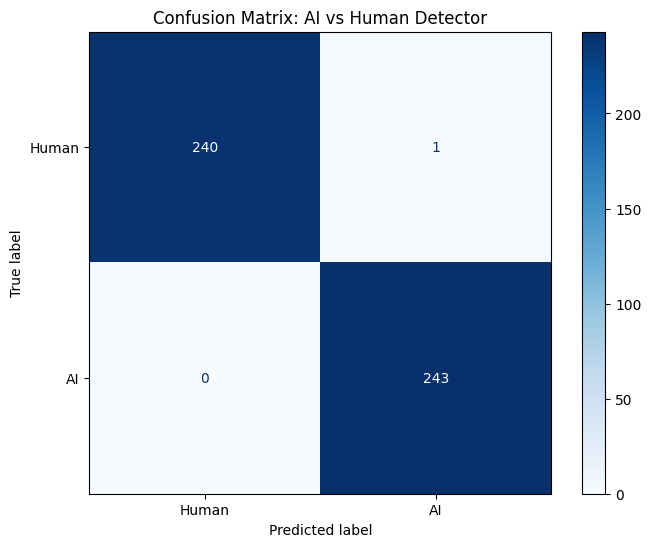

In [ ]:
# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'AI'])

# 3. Plot it
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix: AI vs Human Detector')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=['Human', 'AI']))

              precision    recall  f1-score   support

       Human       1.00      1.00      1.00       241
          AI       1.00      1.00      1.00       243

    accuracy                           1.00       484
   macro avg       1.00      1.00      1.00       484
weighted avg       1.00      1.00      1.00       484



## train the data using new text


In [ ]:
# Saves the model and tokenizer to a folder
trainer.save_model("./freezing_ai_detector_model")
tokenizer.save_pretrained("./freezing_ai_detector_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./freezing_ai_detector_model/tokenizer_config.json',
 './freezing_ai_detector_model/tokenizer.json')

### Freeze Layer Optimization Experiment: Training Time vs. Performance

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00


In [ ]:


import time
import numpy as np
import matplotlib.pyplot as plt
import evaluate
from transformers import RobertaForSequenceClassification, Trainer, TrainingArguments

# Function to calculate accuracy
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# List of freeze layers to test
layers_to_freeze = [0, 4, 8, 10, 11, 12]
experiment_results = []

for freeze_count in layers_to_freeze:
    print(f"\n{'='*40}\nTesting with {freeze_count} frozen layers...\n{'='*40}")

    # 1. Initialize the model (load a new model for each iteration)
    model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

    # 2. Freeze Embedding layer (Common)
    for param in model.roberta.embeddings.parameters():
        param.requires_grad = False

    # 3. Freeze encoder layers up to the specified count
    for layer in model.roberta.encoder.layer[:freeze_count]:
        for param in layer.parameters():
            param.requires_grad = False

    # Calculate trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")

    # 4. Training configuration (Minimize output)
    training_args = TrainingArguments(
        output_dir=f'./temp_freeze_{freeze_count}',
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,
        weight_decay=0.01,
        report_to="none", # Prevent unnecessary logging
        fp16=True, # Mixed Precision for speedup
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_ds['train'],
        eval_dataset=tokenized_ds['validation'],
        compute_metrics=compute_metrics
    )

    # 5. Train and measure time
    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    # 6. Evaluate on the test dataset
    test_results = trainer.evaluate(tokenized_ds['test'])

    # 7. Save results
    experiment_results.append({
        'frozen_layers': freeze_count,
        'train_time': train_time,
        'accuracy': test_results.get('eval_accuracy', 0.0),
        'trainable_params_pct': 100 * trainable_params / total_params
    })

    print(f"-> Train Time: {train_time:.2f}s | Test Accuracy: {test_results.get('eval_accuracy', 0.0):.4f}")

print("\nExperiment Complete!")


Testing with 0 frozen layers...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 85,646,594 (68.71%)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.000160,1.000000


...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 592,130 (0.48%)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.664493,0.946281


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

-> Train Time: 14.39s | Test Accuracy: 0.9298

Experiment Complete!


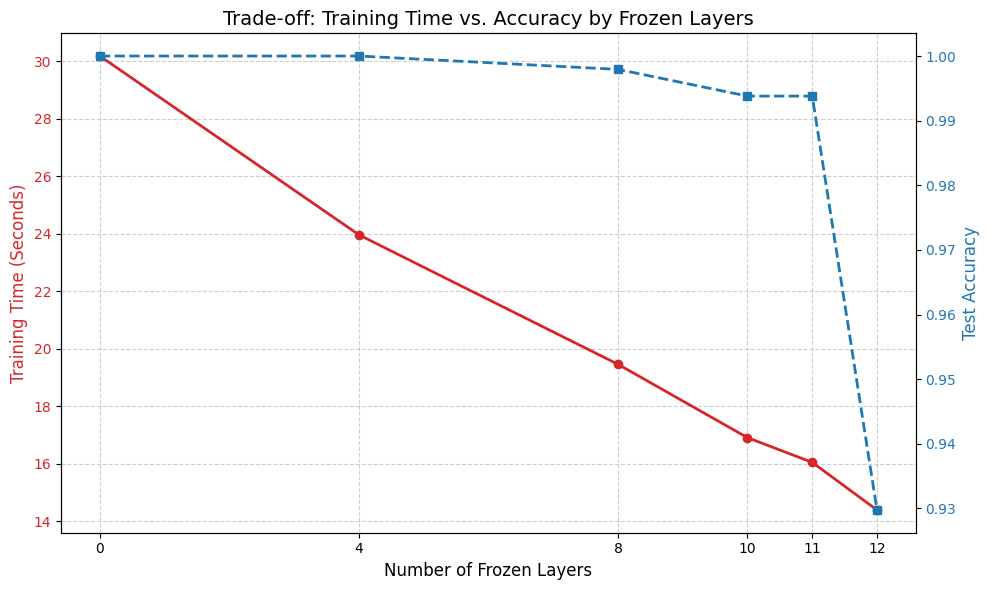

,frozen_layers,train_time,accuracy,trainable_params_pct
0,0,30.176833,1.000000,68.711222
1,4,23.960456,1.000000,45.965830
2,8,19.459514,0.997934,23.220437
3,10,16.908426,0.993802,11.847741
4,11,16.048136,0.993802,6.161393
5,12,14.391736,0.929752,0.475045


In [ ]:
# Visualize the experiment results
layers = [res['frozen_layers'] for res in experiment_results]
times = [res['train_time'] for res in experiment_results]
accuracies = [res['accuracy'] for res in experiment_results]

fig, ax1 = plt.subplots(figsize=(10, 6))

# X-axis: Frozen Layers
# Y-axis 1 (Left): Training Time (Seconds)
color = 'tab:red'
ax1.set_xlabel('Number of Frozen Layers', fontsize=12)
ax1.set_ylabel('Training Time (Seconds)', color=color, fontsize=12)
ax1.plot(layers, times, marker='o', color=color, linewidth=2, label='Training Time')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# Y-axis 2 (Right): Accuracy
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Test Accuracy', color=color, fontsize=12)
ax2.plot(layers, accuracies, marker='s', color=color, linewidth=2, linestyle='dashed', label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout
plt.title('Trade-off: Training Time vs. Accuracy by Frozen Layers', fontsize=14)
fig.tight_layout()
plt.xticks(layers)
plt.show()

# Display results table
import pandas as pd
results_df = pd.DataFrame(experiment_results)
display(results_df)

### LoRA (Low-Rank Adaptation) Finetunig


In [ ]:
!pip install peft

In [ ]:
import time
import evaluate
import numpy as np
from transformers import RobertaForSequenceClassification, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType

# 1. Load original model (for classification)
model_base = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

# 2. LoRA configuration (Creating the 'post-it' adapter)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, # Sequence classification task
    r=8,                        # Rank of the adapter - smaller is lighter
    lora_alpha=16,              # Scaling factor
    target_modules=["query", "value"], # Attach only to query and value modules of attention
    lora_dropout=0.1            # Prevent overfitting
)

# 3. Attach LoRA to the model (At this moment, the original model is 100% frozen)
lora_model = get_peft_model(model_base, lora_config)

print("\n[Check LoRA trainable parameters]")
lora_model.print_trainable_parameters()

# 4. Prepare evaluation metric function
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# 5. Training setup (LoRA usually uses a slightly higher learning rate than standard fine-tuning)
training_args_lora = TrainingArguments(
    output_dir='./lora_ai_detector',
    eval_strategy="epoch",
    learning_rate=2e-4, # Set higher than freezing experiment (2e-5)
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    fp16=True, # Mixed precision for speed improvement
)

lora_trainer = Trainer(
    model=lora_model,
    args=training_args_lora,
    train_dataset=tokenized_ds['train'],
    eval_dataset=tokenized_ds['validation'],
    compute_metrics=compute_metrics
)

# 6. Start training and measure time
print("\n[Start LoRA training...]")
start_time = time.time()
lora_trainer.train()
lora_train_time = time.time() - start_time

# 7. Evaluate on test set
lora_test_results = lora_trainer.evaluate(tokenized_ds['test'])

# 8. Print final results
print(f"\n{'='*40}")
print(f"--- LoRA Experiment Results ---")
print(f"Training Time: {lora_train_time:.2f} seconds")
print(f"Test Accuracy: {lora_test_results.get('eval_accuracy', 0.0):.4f}")
print(f"{'='*40}")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[Check LoRA trainable parameters]
trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066

[Start LoRA training...]


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.013882,0.995868



--- LoRA Experiment Results ---
Training Time: 32.51 seconds
Test Accuracy: 1.0000


### Visualize LoRA vs Layer Freezing
Let's compare the LoRA results with the previous layer freezing experiments.

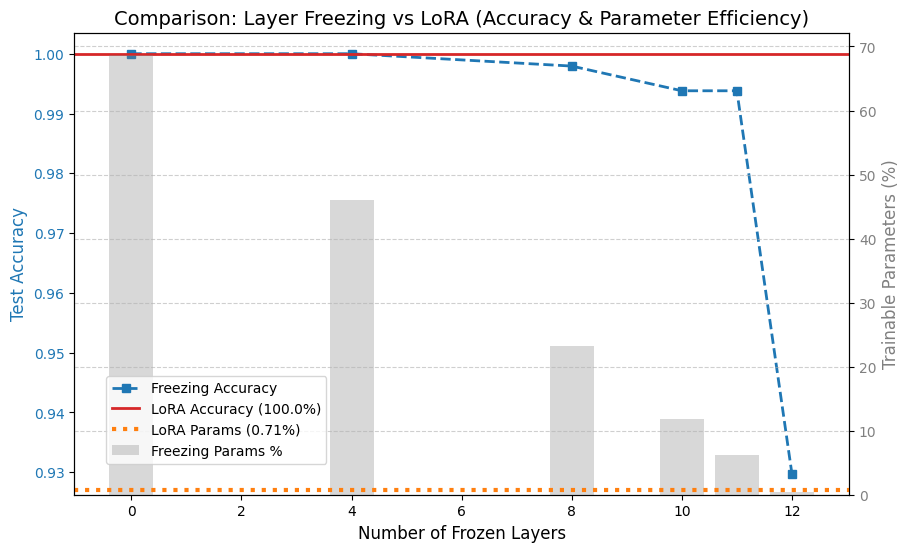

,Method,Accuracy (%),Trainable Params (%)
0,Freeze 0 Layers,100.000000,68.711222
1,Freeze 4 Layers,100.000000,45.965830
2,Freeze 8 Layers,99.793388,23.220437
3,Freeze 10 Layers,99.380165,11.847741
4,Freeze 11 Layers,99.380165,6.161393
5,Freeze 12 Layers,92.975207,0.475045
6,LoRA (r=8),100.000000,0.706600


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data from previous freezing experiment
layers = [res['frozen_layers'] for res in experiment_results]
accuracies = [res['accuracy'] for res in experiment_results]
params_pct = [res['trainable_params_pct'] for res in experiment_results]

# LoRA data (from the recently executed cell)
lora_accuracy = lora_test_results.get('eval_accuracy', 0.0)
lora_params_pct = 0.7066 # Value printed from lora_model.print_trainable_parameters()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Freezing Accuracy
ax1.plot(layers, accuracies, marker='s', color='tab:blue', linewidth=2, linestyle='dashed', label='Freezing Accuracy')
ax1.set_xlabel('Number of Frozen Layers', fontsize=12)
ax1.set_ylabel('Test Accuracy', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Add LoRA Accuracy as a distinct horizontal line or point
ax1.axhline(y=lora_accuracy, color='tab:red', linestyle='-', linewidth=2, label=f'LoRA Accuracy ({lora_accuracy*100:.1f}%)')

# Create a secondary y-axis for Trainable Parameters %
ax2 = ax1.twinx()
ax2.bar(layers, params_pct, alpha=0.3, color='gray', label='Freezing Params %')
ax2.set_ylabel('Trainable Parameters (%)', color='gray', fontsize=12)
ax2.tick_params(axis='y', labelcolor='gray')

# Add LoRA Parameters %
ax2.axhline(y=lora_params_pct, color='tab:orange', linestyle=':', linewidth=3, label=f'LoRA Params ({lora_params_pct:.2f}%)')

# Title and Legend
plt.title('Comparison: Layer Freezing vs LoRA (Accuracy & Parameter Efficiency)', fontsize=14)
fig.legend(loc='lower left', bbox_to_anchor=(0.15, 0.15))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Summary DataFrame
summary_data = []
for res in experiment_results:
    summary_data.append({
        'Method': f"Freeze {res['frozen_layers']} Layers",
        'Accuracy (%)': res['accuracy'] * 100,
        'Trainable Params (%)': res['trainable_params_pct']
    })
summary_data.append({
    'Method': 'LoRA (r=8)',
    'Accuracy (%)': lora_accuracy * 100,
    'Trainable Params (%)': lora_params_pct
})

display(pd.DataFrame(summary_data))

### Training Time Comparison: Freezing vs LoRA
Now let's look at the training time. While LoRA has very few trainable parameters, the actual computation time might not be the absolute shortest because of the overhead of calculating the adapter layers during the forward and backward passes.

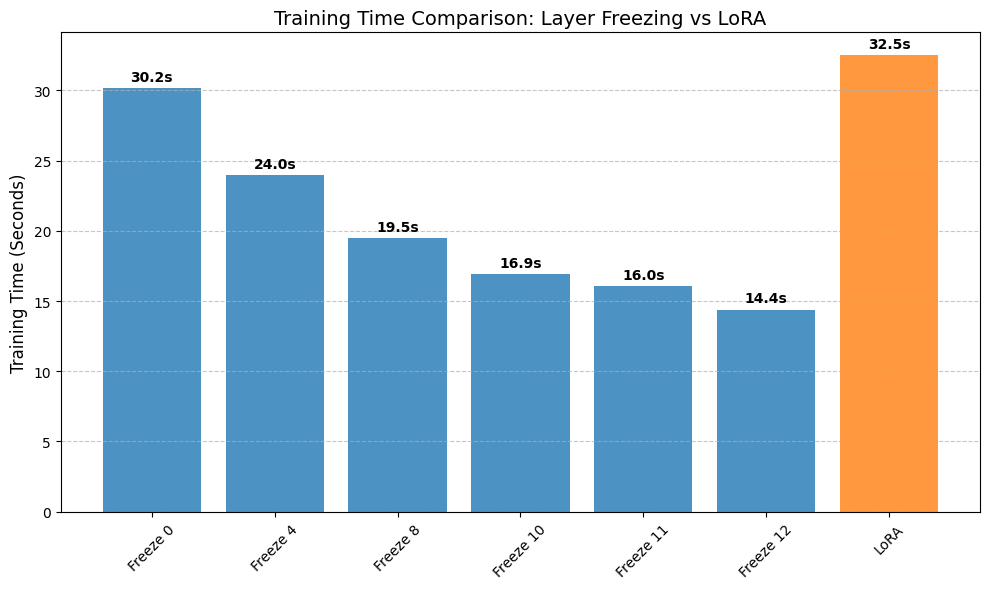

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for time comparison
methods = [f"Freeze {res['frozen_layers']}" for res in experiment_results]
times = [res['train_time'] for res in experiment_results]

# Add LoRA to the lists
methods.append("LoRA")
times.append(lora_train_time)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tab:blue'] * len(experiment_results) + ['tab:orange'] # Orange for LoRA
bars = ax.bar(methods, times, color=colors, alpha=0.8)

ax.set_ylabel('Training Time (Seconds)', fontsize=12)
ax.set_title('Training Time Comparison: Layer Freezing vs LoRA', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of bars for exact values
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f'{yval:.1f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Out-of-Domain (OOD) Testing
Let's create a tiny custom dataset to see if the model truly understands "AI vs Human" or if it just overfit to the specific dataset we used for training. We will use typical AI cliches and casual human internet slang.

In [ ]:
import pandas as pd
from datasets import Dataset
import numpy as np

# 1. Create a custom Out-of-Domain (OOD) dataset
# label 0: Human, label 1: AI
ood_data = [
    {"text": "Bro this movie was literally insane fr fr 🔥 totally recommend it.", "label": 0}, # Casual human internet slang
    {"text": "As an AI language model, I do not have personal opinions or feelings.", "label": 1}, # Classic AI refusal
    {"text": "In conclusion, the multifaceted nature of this issue underscores the importance of further research.", "label": 1}, # Formal AI boilerplate
    {"text": "I was walking down the street yesterday and saw a dog wearing a tiny hat. It made my day!", "label": 0}, # Casual human storytelling
    {"text": "To delve into the intricacies of quantum mechanics, one must first understand its fundamental principles.", "label": 1}, # 'Delve' is famously overused by LLMs
    {"text": "idk man seem kinda sus to me tbh, maybe we just wait and see", "label": 0}, # Heavy internet slang / lowercase
    {"text": "Here is a comprehensive list of 5 things you can do to improve your productivity today:", "label": 1}, # AI listicle introduction
    {"text": "Just finished my workout and I am absolutely exhausted. Time for a huge pizza.", "label": 0} # Normal human status update
]

ood_df = pd.DataFrame(ood_data)

# 2. Convert to Hugging Face Dataset
ood_dataset = Dataset.from_pandas(ood_df)

# 3. Tokenize using the previously defined tokenize_fn
ood_tokenized = ood_dataset.map(tokenize_fn, batched=True)

# 4. Predict using the trained LoRA model
ood_predictions = lora_trainer.predict(ood_tokenized)
ood_preds = np.argmax(ood_predictions.predictions, axis=-1)

# 5. Add predictions to the DataFrame to compare
ood_df['prediction'] = ood_preds
ood_df['is_correct'] = ood_df['label'] == ood_df['prediction']

# Map 0/1 back to labels for easier reading
label_map = {0: 'Human', 1: 'AI'}
ood_df['label_name'] = ood_df['label'].map(label_map)
ood_df['prediction_name'] = ood_df['prediction'].map(label_map)

print("\n--- Out-of-Domain Test Results ---")
display(ood_df[['text', 'label_name', 'prediction_name', 'is_correct']])
print(f"\nOOD Accuracy: {ood_df['is_correct'].mean() * 100:.2f}%")

Map:   0%|          | 0/8 [00:00<?, ? examples/s]


--- Out-of-Domain Test Results ---


,text,label_name,prediction_name,is_correct
0,Bro this movie was literally insane fr fr 🔥 to...,Human,AI,False
1,"As an AI language model, I do not have persona...",AI,AI,True
2,"In conclusion, the multifaceted nature of this...",AI,AI,True
3,I was walking down the street yesterday and sa...,Human,AI,False
4,To delve into the intricacies of quantum mecha...,AI,AI,True
5,"idk man seem kinda sus to me tbh, maybe we jus...",Human,AI,False
6,Here is a comprehensive list of 5 things you c...,AI,AI,True
7,Just finished my workout and I am absolutely e...,Human,AI,False



OOD Accuracy: 50.00%


### Real Out-of-Domain Testing with Hugging Face Dataset (HC3)
Let's download a real dataset (`Hello-SimpleAI/HC3`), format it into our `text` and `label` format, and evaluate both of our trained models to see how they generalize to completely unseen, real-world data.

In [ ]:
import pandas as pd

print("Downloading HC3 dataset directly via JSONL...")
try:
    hc3_df = pd.read_json("hf://datasets/Hello-SimpleAI/HC3/all.jsonl", lines=True)
except Exception:
    # hf:// 프로토콜을 지원하지 않는 환경일 경우 직접 URL을 통해 다운로드
    hc3_df = pd.read_json("https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/all.jsonl", lines=True)

# Sample 100 random rows to keep evaluation fast
hc3_sampled = hc3_df.sample(n=100, random_state=42).reset_index(drop=True)

ood_texts = []
ood_labels = []

# Extract human and AI answers
for _, row in hc3_sampled.iterrows():
    # human_answers is a list of strings
    if isinstance(row["human_answers"], list) and len(row["human_answers"]) > 0:
        ood_texts.append(row["human_answers"][0])
        ood_labels.append(0) # 0 for Human

    # chatgpt_answers is a list of strings
    if isinstance(row["chatgpt_answers"], list) and len(row["chatgpt_answers"]) > 0:
        ood_texts.append(row["chatgpt_answers"][0])
        ood_labels.append(1) # 1 for AI

# Create DataFrame
hf_ood_df = pd.DataFrame({"text": ood_texts, "label": ood_labels})
print(f"\nCreated Real OOD dataset with {len(hf_ood_df)} samples.")
display(hf_ood_df.head())



Created Real OOD dataset with 198 samples.


,text,label
0,The windows are aligned with the structural sp...,0
1,Airplane windows are not aligned with the seat...,1
2,Have you not tried bacon before ? It 's really...,0
3,Bacon is a type of meat that is made from the ...,1
4,My opinion on this is that it is as common now...,0


Map:   0%|          | 0/198 [00:00<?, ? examples/s]


[Evaluating on Freezing Model...]


-> Freezing Model OOD Accuracy: 84.34%

[Evaluating on LoRA Model...]


-> LoRA Model OOD Accuracy: 50.00%


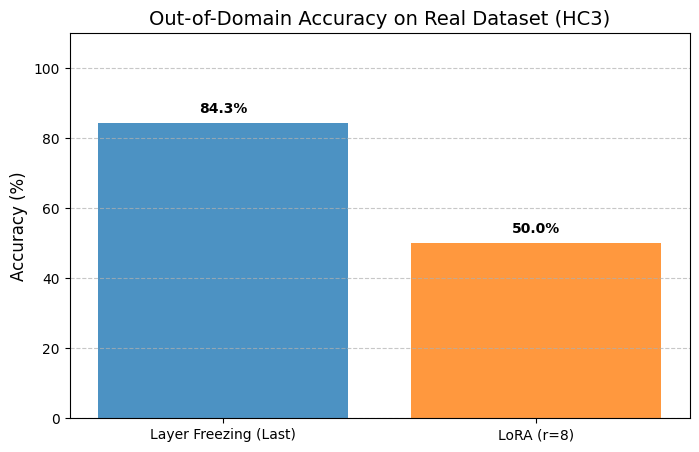

In [ ]:
from datasets import Dataset
import matplotlib.pyplot as plt

# 1. Convert to Hugging Face Dataset & Tokenize
hf_ood_dataset = Dataset.from_pandas(hf_ood_df)
hf_ood_tokenized = hf_ood_dataset.map(tokenize_fn, batched=True)

# 2. Evaluate on the Freezing Model (Last state of standard Trainer)
print("\n[Evaluating on Freezing Model...]")
freeze_ood_results = trainer.evaluate(hf_ood_tokenized)
freeze_acc = freeze_ood_results.get('eval_accuracy', 0.0) * 100
print(f"-> Freezing Model OOD Accuracy: {freeze_acc:.2f}%")

# 3. Evaluate on the LoRA Model
print("\n[Evaluating on LoRA Model...]")
lora_ood_results = lora_trainer.evaluate(hf_ood_tokenized)
lora_acc = lora_ood_results.get('eval_accuracy', 0.0) * 100
print(f"-> LoRA Model OOD Accuracy: {lora_acc:.2f}%")

# 4. Visualize the comparison
models = ['Layer Freezing (Last)', 'LoRA (r=8)']
accuracies = [freeze_acc, lora_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['tab:blue', 'tab:orange'], alpha=0.8)
plt.title('Out-of-Domain Accuracy on Real Dataset (HC3)', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 110)

# Add text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Comprehensive OOD Evaluation: All Freezing Layers & LoRA
Let's evaluate how *each* model configuration handles the Out-of-Domain (OOD) HC3 dataset. We will quickly retrain the frozen models and immediately evaluate them to collect the accuracy.

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from transformers import RobertaForSequenceClassification, Trainer, TrainingArguments
import evaluate
import torch
import gc

print("Re-evaluating all freezing configurations on OOD dataset (HC3)...")
print("This will take about 1~2 minutes.\n")

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

layers_to_freeze = [0, 4, 8, 10, 11, 12]
comprehensive_results = []

for freeze_count in layers_to_freeze:
    print(f"[{freeze_count} Layers Frozen] Training & Evaluating...")

    # 1. Initialize the model
    model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

    # 2. Freeze Embedding layer
    for param in model.roberta.embeddings.parameters():
        param.requires_grad = False

    # 3. Freeze encoder layers
    for layer in model.roberta.encoder.layer[:freeze_count]:
        for param in layer.parameters():
            param.requires_grad = False

    # 4. Training configuration
    training_args = TrainingArguments(
        output_dir=f'./temp_eval_{freeze_count}',
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,
        weight_decay=0.01,
        report_to="none",
        fp16=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_ds['train'],
        eval_dataset=tokenized_ds['validation'],
        compute_metrics=compute_metrics
    )

    # Train briefly
    trainer.train()

    # Evaluate on In-Domain Test
    id_results = trainer.evaluate(tokenized_ds['test'])
    id_acc = id_results.get('eval_accuracy', 0.0) * 100

    # Evaluate on Out-of-Domain Test (HC3)
    ood_results = trainer.evaluate(hf_ood_tokenized)
    ood_acc = ood_results.get('eval_accuracy', 0.0) * 100

    comprehensive_results.append({
        'Model': f'Freeze {freeze_count}',
        'ID_Accuracy': id_acc,
        'OOD_Accuracy': ood_acc
    })
    print(f"-> ID Acc: {id_acc:.2f}% | OOD Acc: {ood_acc:.2f}%\n")

    # Free memory to prevent OOM
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

# --- Evaluate LoRA (Using the already trained lora_trainer) ---
print("[LoRA] Evaluating existing model...")
lora_id_results = lora_trainer.evaluate(tokenized_ds['test'])
lora_ood_results = lora_trainer.evaluate(hf_ood_tokenized)

lora_id_acc = lora_id_results.get('eval_accuracy', 0.0) * 100
lora_ood_acc = lora_ood_results.get('eval_accuracy', 0.0) * 100

comprehensive_results.append({
    'Model': 'LoRA (r=8)',
    'ID_Accuracy': lora_id_acc,
    'OOD_Accuracy': lora_ood_acc
})
print(f"-> ID Acc: {lora_id_acc:.2f}% | OOD Acc: {lora_ood_acc:.2f}%\n")

print("Evaluation Complete!")

Re-evaluating all freezing configurations on OOD dataset (HC3)...
This will take about 1~2 minutes.

[0 Layers Frozen] Training & Evaluating...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.015111,0.997934


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.663194,0.954545


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

-> ID Acc: 94.42% | OOD Acc: 83.84%

[LoRA] Evaluating existing model...


-> ID Acc: 100.00% | OOD Acc: 50.00%

Evaluation Complete!


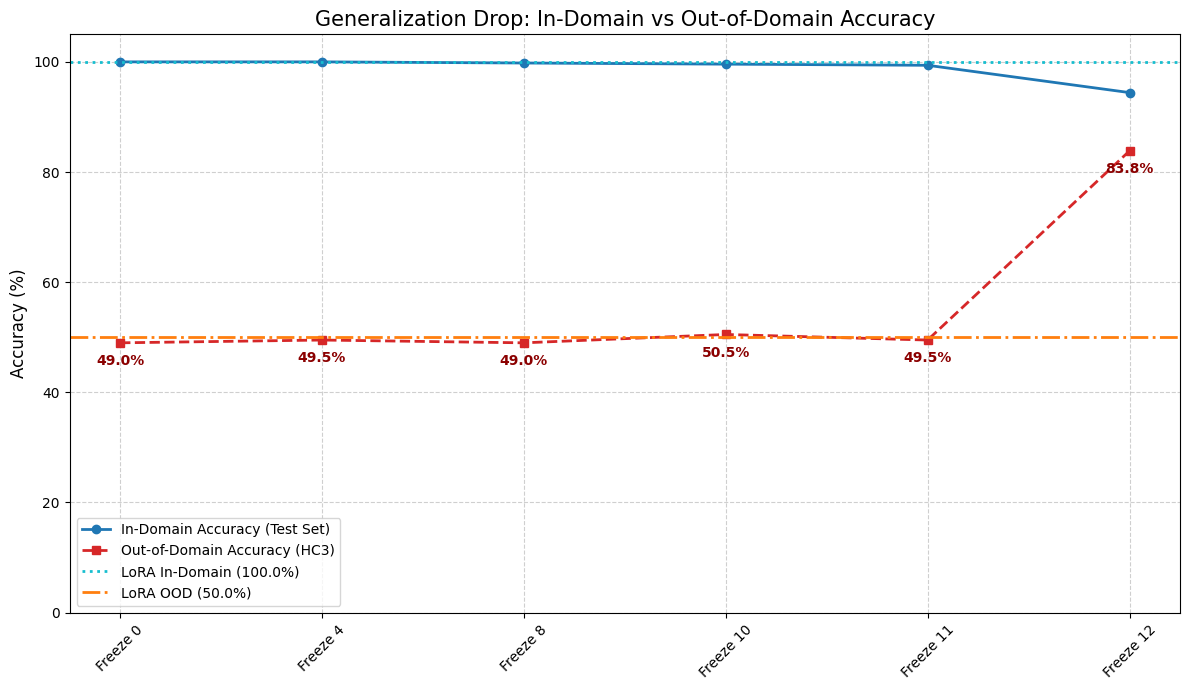

,Model,ID_Accuracy,OOD_Accuracy
0,Freeze 0,100.000000,48.989899
1,Freeze 4,100.000000,49.494949
2,Freeze 8,99.793388,48.989899
3,Freeze 10,99.586777,50.505051
4,Freeze 11,99.380165,49.494949
5,Freeze 12,94.421488,83.838384
6,LoRA (r=8),100.000000,50.000000


In [ ]:
# 1. Visualize the Results
df_comp = pd.DataFrame(comprehensive_results)

# Extracting data for plotting
freeze_df = df_comp[df_comp['Model'].str.contains('Freeze')]
lora_row = df_comp[df_comp['Model'] == 'LoRA (r=8)'].iloc[0]

x_labels = freeze_df['Model']
x_pos = np.arange(len(x_labels))

fig, ax = plt.subplots(figsize=(12, 7))

# Plot Freezing ID vs OOD Accuracies
ax.plot(x_pos, freeze_df['ID_Accuracy'], marker='o', color='tab:blue', linewidth=2, label='In-Domain Accuracy (Test Set)')
ax.plot(x_pos, freeze_df['OOD_Accuracy'], marker='s', color='tab:red', linestyle='dashed', linewidth=2, label='Out-of-Domain Accuracy (HC3)')

# Add LoRA as horizontal lines for comparison
ax.axhline(y=lora_row['ID_Accuracy'], color='tab:cyan', linestyle=':', linewidth=2, label=f"LoRA In-Domain ({lora_row['ID_Accuracy']:.1f}%)")
ax.axhline(y=lora_row['OOD_Accuracy'], color='tab:orange', linestyle='-.', linewidth=2, label=f"LoRA OOD ({lora_row['OOD_Accuracy']:.1f}%)")

# Formatting the plot
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Generalization Drop: In-Domain vs Out-of-Domain Accuracy', fontsize=15)
ax.grid(True, linestyle='--', alpha=0.6)

# Add text annotations for OOD Accuracy to highlight the drop
for i, val in enumerate(freeze_df['OOD_Accuracy']):
    ax.text(i, val - 4, f"{val:.1f}%", ha='center', color='darkred', fontweight='bold')

ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

# 2. Display the Dataframe
display(df_comp)

## Report: Analysis of Generalization Drop and Catastrophic Forgetting

### 1. Observation: The "Accuracy Collapse"
During our experiment to classify Human vs. AI-generated text, we observed a stark contrast between **In-Domain (ID)** and **Out-of-Domain (OOD)** performance across different fine-tuning configurations of the RoBERTa model.

*   **Deep Fine-Tuning & LoRA (Freeze 0-11 & LoRA):** These models achieved near-perfect accuracy (~100%) on the ID test set. However, when tested on a completely unseen, real-world dataset (HC3), their accuracy plummeted to roughly **50%**, which is equivalent to random guessing.
*   **Linear Probing (Freeze 12):** The model with all 12 encoder layers frozen (only the final classification head was trained) achieved a slightly lower ID accuracy (~94.4%). Surprisingly, it vastly outperformed all other methods on the OOD dataset, maintaining a robust **83.8%** accuracy.

### 2. Why Did the "Dumbest" Setting Win?
The counter-intuitive success of "Freeze 12" perfectly illustrates two critical phenomena in Machine Learning:

#### A. Spurious Correlations and Overfitting
Our initial training dataset was likely too simplistic and contained superficial patterns (e.g., specific vocabulary, sentence length biases). When we allowed the model to update its internal weights (Freeze 0-11 and LoRA), it took the path of least resistance. It memorized these biased "shortcuts" rather than learning the deep, semantic differences between AI and Human text. When presented with the HC3 dataset where these shortcuts didn't exist, the models completely failed.

#### B. Catastrophic Forgetting vs. Representation Preservation
RoBERTa was pre-trained on massive amounts of text, developing a highly sophisticated understanding of language.
*   When we fine-tuned the encoder layers on our small, biased dataset, we accidentally overwrote and destroyed this valuable pre-trained knowledge (**Catastrophic Forgetting**).
*   By freezing all 12 layers (**Linear Probing**), we protected the model's "brain." The base model simply extracted high-quality linguistic features based on its original pre-training, and we only trained a simple switch (the classification head) to map those features to our labels. This preserved the model's generalization capabilities, allowing it to perform well on the unseen HC3 data.

### 3. Conclusion & Next Steps
This experiment strongly demonstrates a core principle of **Data-Centric AI**: a model is only as good as its data.

The failure of the deeply fine-tuned models on OOD data proves that our training dataset is insufficient for real-world application. To build a truly robust AI detector, our next step must be to heavily augment our training data with diverse, challenging, and representative samples (like the HC3 dataset) rather than focusing on complex training algorithms.

### Step 2: Building a Robust Dataset (Data-Centric AI)
Let's augment our original training dataset with a larger chunk of the HC3 dataset. This will force the model to learn deep semantic differences rather than overfitting to the superficial quirks of our initial dataset.

In [ ]:
import pandas as pd

# 1. Check original dataset size
print(f"Original dataset size: {len(df)}")

# 2. Sample a larger chunk from the already downloaded HC3 dataset
# Let's take 1000 rows (which gives up to 1000 human and 1000 AI texts)
hc3_train_sampled = hc3_df.sample(n=1000, random_state=123).reset_index(drop=True)

new_texts = []
new_labels = []

for _, row in hc3_train_sampled.iterrows():
    if isinstance(row["human_answers"], list) and len(row["human_answers"]) > 0:
        new_texts.append(row["human_answers"][0])
        new_labels.append(0) # Human

    if isinstance(row["chatgpt_answers"], list) and len(row["chatgpt_answers"]) > 0:
        new_texts.append(row["chatgpt_answers"][0])
        new_labels.append(1) # AI

hf_new_df = pd.DataFrame({"text": new_texts, "label": new_labels})
print(f"New HC3 data to add: {len(hf_new_df)}")

# 3. Concatenate original data with the new HC3 data
robust_df = pd.concat([df, hf_new_df], ignore_index=True)

# 4. Shuffle the combined dataset thoroughly
robust_df = robust_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal Robust Dataset size: {len(robust_df)}")
print("\nClass Distribution:")
print(robust_df['label'].value_counts())

display(robust_df.head())

Original dataset size: 4836
New HC3 data to add: 1980

Total Robust Dataset size: 6816

Class Distribution:
label
0    3412
1    3404
Name: count, dtype: int64


,text,label
0,"new video loaded:Amid Fires, Indonesia Welcome...",0
1,the foundation for a historic agreement when t...,1
2,blending elements of folk and R&B to create a ...,1
3,House Hunting in ... Montreal A three-story st...,0
4,"The words ""first,"" ""second,"" ""third,"" and so o...",1


Now that we have `robust_df`, you can simply split it into Train/Val/Test exactly as you did at the beginning, tokenize it, and pass it to your existing Trainer or LoRA setup!

### Step 3: Train & Evaluate on the Robust Dataset
Let's run our pipeline on the new `robust_df` using LoRA.

In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import RobertaForSequenceClassification, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
import time
import evaluate
import numpy as np

# 1. Train / Val / Test Split
robust_train, temp_df = train_test_split(robust_df, test_size=0.2, stratify=robust_df['label'], random_state=42)
robust_val, robust_test = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"Robust Train: {len(robust_train)} | Val: {len(robust_val)} | Test: {len(robust_test)}")

# 2. Convert to Hugging Face Dataset & Tokenize
robust_dataset = DatasetDict({
    'train': Dataset.from_pandas(robust_train),
    'validation': Dataset.from_pandas(robust_val),
    'test': Dataset.from_pandas(robust_test)
})

# Clean up index column if pandas left it
for split in robust_dataset.keys():
    if "__index_level_0__" in robust_dataset[split].column_names:
        robust_dataset[split] = robust_dataset[split].remove_columns(["__index_level_0__"])

robust_tokenized = robust_dataset.map(tokenize_fn, batched=True)

# 3. Initialize Base Model & LoRA
robust_base_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16,
    target_modules=["query", "value"], lora_dropout=0.1
)
robust_lora_model = get_peft_model(robust_base_model, lora_config)

# 4. Train
robust_training_args = TrainingArguments(
    output_dir='./robust_lora_model',
    eval_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    fp16=True,
    report_to="none"
)

robust_trainer = Trainer(
    model=robust_lora_model,
    args=robust_training_args,
    train_dataset=robust_tokenized['train'],
    eval_dataset=robust_tokenized['validation'],
    compute_metrics=compute_metrics
)

print("\n[Training Robust LoRA Model...]")
start_time = time.time()
robust_trainer.train()
robust_lora_train_time = time.time() - start_time # 저장
print(f"Training took {robust_lora_train_time:.2f} seconds")

# 5. Evaluate on its own Test set (which now includes HC3 data)
robust_test_results = robust_trainer.evaluate(robust_tokenized['test'])
print(f"\nRobust Model Test Accuracy: {robust_test_results.get('eval_accuracy', 0.0) * 100:.2f}%")

Robust Train: 5452 | Val: 682 | Test: 682


Map:   0%|          | 0/5452 [00:00<?, ? examples/s]

Map:   0%|          | 0/682 [00:00<?, ? examples/s]

Map:   0%|          | 0/682 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[Training Robust LoRA Model...]


Epoch,Training Loss,Validation Loss,Accuracy
1,0.170379,0.110993,0.973607


Training took 43.49 seconds



Robust Model Test Accuracy: 98.24%


### Robust Dataset Experiment: Freezing Layers vs LoRA
Let's run the layer freezing ablation study again, but this time using our new `robust_tokenized` dataset to see how a higher-quality dataset affects generalization and capacity.

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from transformers import RobertaForSequenceClassification, Trainer, TrainingArguments
import evaluate
import torch
import gc

print("Running Freeze Experiment on Robust Dataset...")
print("This might take a few minutes as the dataset is larger now.\n")

layers_to_freeze = [0, 4, 8, 10, 11, 12]
robust_experiment_results = []

for freeze_count in layers_to_freeze:
    print(f"[{freeze_count} Layers Frozen] Training & Evaluating...")

    # 1. Initialize the model
    model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

    # 2. Freeze Embedding layer
    for param in model.roberta.embeddings.parameters():
        param.requires_grad = False

    # 3. Freeze encoder layers
    for layer in model.roberta.encoder.layer[:freeze_count]:
        for param in layer.parameters():
            param.requires_grad = False

    # Calculate trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    params_pct = 100 * trainable_params / total_params

    # 4. Training configuration
    training_args = TrainingArguments(
        output_dir=f'./robust_freeze_{freeze_count}',
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,
        weight_decay=0.01,
        report_to="none",
        fp16=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=robust_tokenized['train'],
        eval_dataset=robust_tokenized['validation'],
        compute_metrics=compute_metrics
    )

    # 5. Train and measure time
    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    # 6. Evaluate on Robust Test
    test_results = trainer.evaluate(robust_tokenized['test'])
    acc = test_results.get('eval_accuracy', 0.0) * 100

    robust_experiment_results.append({
        'Model': f'Freeze {freeze_count}',
        'Frozen_Layers': freeze_count,
        'Train_Time': train_time,
        'Accuracy': acc,
        'Params_Pct': params_pct
    })
    print(f"-> Train Time: {train_time:.2f}s | Test Acc: {acc:.2f}%\n")

    # Free memory
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

print("Experiment Complete!")

Running Freeze Experiment on Robust Dataset...
This might take a few minutes as the dataset is larger now.

[0 Layers Frozen] Training & Evaluating...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.120584,0.080659,0.988270


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.667992,0.649458,0.746334


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

-> Train Time: 21.08s | Test Acc: 80.21%

Experiment Complete!


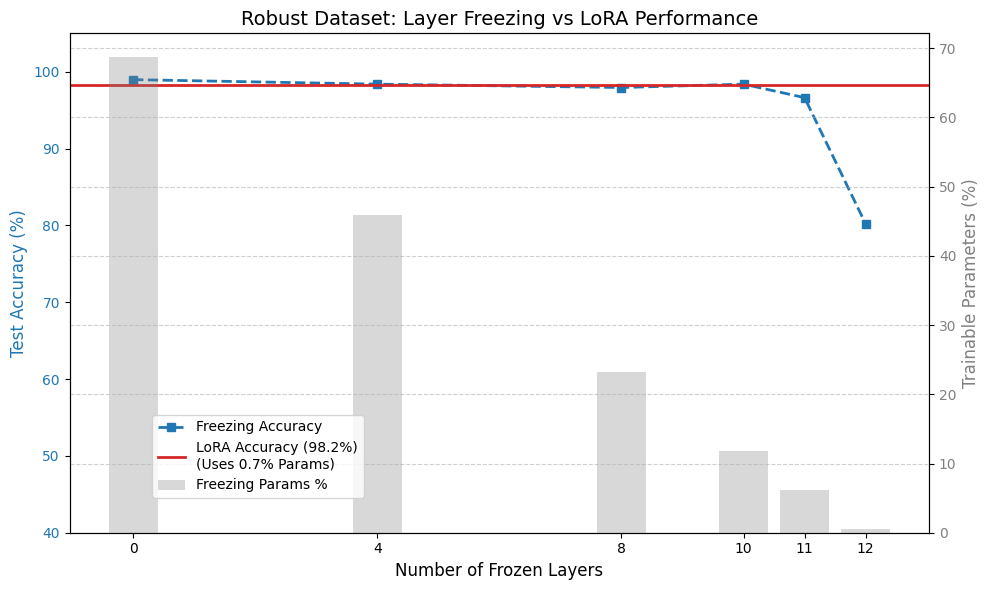

,Model,Frozen_Layers,Train_Time,Accuracy,Params_Pct
0,Freeze 0,0,42.243516,98.973607,68.711222
1,Freeze 4,4,35.253910,98.387097,45.965830
2,Freeze 8,8,27.960673,97.947214,23.220437
3,Freeze 10,10,24.651471,98.387097,11.847741
4,Freeze 11,11,22.896655,96.627566,6.161393
5,Freeze 12,12,21.077186,80.205279,0.475045
6,LoRA (r=8),N/A,43.493534,98.240469,0.706600


In [ ]:
# Extract LoRA results from the previous cell
robust_lora_acc = robust_test_results.get('eval_accuracy', 0.0) * 100
# LoRA r=8 roughly uses 0.7% trainable params (we know this from earlier)
robust_lora_params_pct = 0.7066

# Convert results to DataFrame
df_robust_comp = pd.DataFrame(robust_experiment_results)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Freezing Accuracy
ax1.plot(df_robust_comp['Frozen_Layers'], df_robust_comp['Accuracy'], marker='s', color='tab:blue', linewidth=2, linestyle='dashed', label='Freezing Accuracy')
ax1.set_xlabel('Number of Frozen Layers', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(40, 105)

# Add LoRA Accuracy
ax1.axhline(y=robust_lora_acc, color='tab:red', linestyle='-', linewidth=2, label=f'LoRA Accuracy ({robust_lora_acc:.1f}%)\n(Uses 0.7% Params)')

# Create secondary y-axis for Trainable Parameters %
ax2 = ax1.twinx()
ax2.bar(df_robust_comp['Frozen_Layers'], df_robust_comp['Params_Pct'], alpha=0.3, color='gray', label='Freezing Params %')
ax2.set_ylabel('Trainable Parameters (%)', color='gray', fontsize=12)
ax2.tick_params(axis='y', labelcolor='gray')

# Title and Legend
plt.title('Robust Dataset: Layer Freezing vs LoRA Performance', fontsize=14)
fig.legend(loc='lower left', bbox_to_anchor=(0.15, 0.15))
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(df_robust_comp['Frozen_Layers'])
plt.tight_layout()
plt.show()

summary_robust = df_robust_comp.copy()

try:
    lora_time_to_display = robust_lora_train_time
except NameError:
    lora_time_to_display = 'N/A (Run cell eacc7830 first)'

summary_robust.loc[len(summary_robust)] = {
    'Model': 'LoRA (r=8)',
    'Frozen_Layers': 'N/A',
    'Train_Time': lora_time_to_display,
    'Accuracy': robust_lora_acc,
    'Params_Pct': robust_lora_params_pct
}
display(summary_robust)

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import RobertaForSequenceClassification, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
import evaluate
import torch
import gc

print("Running LoRA Rank (r) Experiment on Robust Dataset...")
print("This will test different sizes of LoRA adapters.\n")

# Rank values to test
lora_ranks = [2, 4, 8, 16, 32]
lora_experiment_results = []

for r in lora_ranks:
    print(f"[{'='*40}]\n[Testing LoRA with Rank r={r}]\n[{'='*40}]")

    # 1. Initialize Base Model
    base_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

    # 2. Set LoRA Config (changing only the r value)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=r,
        lora_alpha=16, # Usually, alpha is scaled proportionally to r or kept fixed.
        target_modules=["query", "value"],
        lora_dropout=0.1
    )

    lora_model = get_peft_model(base_model, lora_config)

    # Calculate trainable parameters
    trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in lora_model.parameters())
    params_pct = 100 * trainable_params / total_params
    print(f"-> Trainable Params: {trainable_params:,} ({params_pct:.3f}%)")

    # 3. Training arguments (same conditions)
    training_args = TrainingArguments(
        output_dir=f'./lora_robust_r_{r}',
        eval_strategy="epoch",
        learning_rate=2e-4,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,
        weight_decay=0.01,
        report_to="none",
        fp16=True,
    )

    trainer = Trainer(
        model=lora_model,
        args=training_args,
        train_dataset=robust_tokenized['train'],
        eval_dataset=robust_tokenized['validation'],
        compute_metrics=compute_metrics
    )

    # 4. Train and measure time
    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    # 5. Evaluate on the Robust Test set
    test_results = trainer.evaluate(robust_tokenized['test'])
    acc = test_results.get('eval_accuracy', 0.0) * 100

    lora_experiment_results.append({
        'Rank (r)': r,
        'Train_Time': train_time,
        'Accuracy': acc,
        'Params_Pct': params_pct
    })
    print(f"\n=> Train Time: {train_time:.2f}s | Test Acc: {acc:.2f}%\n")

    # Clear memory to prevent OOM
    del base_model, lora_model, trainer
    gc.collect()
    torch.cuda.empty_cache()

print("LoRA Experiment Complete!")

Running LoRA Rank (r) Experiment on Robust Dataset...
This will test different sizes of LoRA adapters.

[========================================]
[Testing LoRA with Rank r=2]
[========================================]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


-> Trainable Params: 665,858 (0.531%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.163965,0.122671,0.975073


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


-> Trainable Params: 1,771,778 (1.402%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.160336,0.089209,0.980938



=> Train Time: 44.24s | Test Acc: 98.53%

LoRA Experiment Complete!


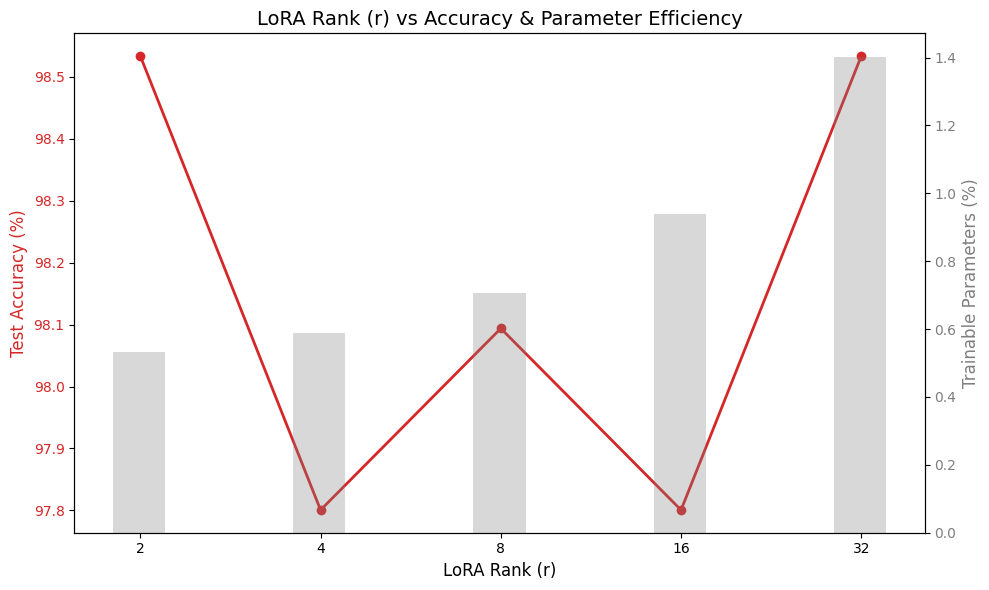

,Rank (r),Train_Time,Accuracy,Params_Pct
0,2,43.740941,98.533724,0.531356
1,4,44.481702,97.800587,0.589844
2,8,43.505620,98.093842,0.706614
3,16,44.975051,97.800587,0.939333
4,32,44.242055,98.533724,1.401513


In [ ]:
# Visualize and display results
df_lora_exp = pd.DataFrame(lora_experiment_results)

fig, ax1 = plt.subplots(figsize=(10, 6))

# X-axis: Rank (r), Y-axis (left): Accuracy
ax1.plot(df_lora_exp['Rank (r)'], df_lora_exp['Accuracy'], marker='o', color='tab:red', linewidth=2, label='Accuracy')
ax1.set_xlabel('LoRA Rank (r)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', color='tab:red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.set_xscale('log', base=2) # Log scale is better since r doubles at each step.
ax1.set_xticks(df_lora_exp['Rank (r)'])
ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())

# Y-axis (right): Parameter Percentage
ax2 = ax1.twinx()
ax2.bar(df_lora_exp['Rank (r)'], df_lora_exp['Params_Pct'], alpha=0.3, color='tab:gray', width=df_lora_exp['Rank (r)']*0.2, label='Trainable Params %')
ax2.set_ylabel('Trainable Parameters (%)', color='tab:gray', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:gray')

plt.title('LoRA Rank (r) vs Accuracy & Parameter Efficiency', fontsize=14)
fig.tight_layout()
plt.show()

display(df_lora_exp)

In [ ]:
print("Evaluating Robust LoRA Model on the Original Dataset's Test Set...")


original_test_results = robust_trainer.evaluate(tokenized_ds['test'])
original_test_acc = original_test_results.get('eval_accuracy', 0.0) * 100

print(f"\n-> Accuracy on Original Test Set (sampled_50): {original_test_acc:.2f}%")

print("\n[Analysis]")
if original_test_acc > 90:
    print("✅ Excellent! The model successfully retained its knowledge of the original domain (no catastrophic forgetting) while learning from the new HC3 data.")
else:
    print("⚠️ Warning: The accuracy on the original data has dropped. The model might have overfitted to the new HC3 dataset.")

Evaluating Robust LoRA Model on the Original Dataset's Test Set...



-> Accuracy on Original Test Set (sampled_50): 99.38%

[Analysis]
✅ Excellent! The model successfully retained its knowledge of the original domain (no catastrophic forgetting) while learning from the new HC3 data.


### Reverse OOD Test: Train on HC3, Evaluate on Sampled50


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

# 1. Create a pure HC3 dataset (sample 2000 questions -> ~3900 answers)
hc3_pure_sampled = hc3_df.sample(n=2000, random_state=99).reset_index(drop=True)

hc3_texts = []
hc3_labels = []

for _, row in hc3_pure_sampled.iterrows():
    if isinstance(row["human_answers"], list) and len(row["human_answers"]) > 0:
        hc3_texts.append(row["human_answers"][0])
        hc3_labels.append(0) # Human
    if isinstance(row["chatgpt_answers"], list) and len(row["chatgpt_answers"]) > 0:
        hc3_texts.append(row["chatgpt_answers"][0])
        hc3_labels.append(1) # AI

hc3_only_df = pd.DataFrame({"text": hc3_texts, "label": hc3_labels})
hc3_only_df = hc3_only_df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Created HC3-Only Dataset Size: {len(hc3_only_df)}")

# 2. Train / Val / Test Split (80% / 10% / 10%)
hc3_train, hc3_temp = train_test_split(hc3_only_df, test_size=0.2, stratify=hc3_only_df['label'], random_state=42)
hc3_val, hc3_test = train_test_split(hc3_temp, test_size=0.5, stratify=hc3_temp['label'], random_state=42)

# 3. Convert to Hugging Face Dataset & Tokenize
hc3_dataset = DatasetDict({
    'train': Dataset.from_pandas(hc3_train),
    'validation': Dataset.from_pandas(hc3_val),
    'test': Dataset.from_pandas(hc3_test)
})

# Clean up index column if exists
for split in hc3_dataset.keys():
    if "__index_level_0__" in hc3_dataset[split].column_names:
        hc3_dataset[split] = hc3_dataset[split].remove_columns(["__index_level_0__"])

hc3_tokenized = hc3_dataset.map(tokenize_fn, batched=True)
print("Tokenization Complete!")

Created HC3-Only Dataset Size: 3974


Map:   0%|          | 0/3179 [00:00<?, ? examples/s]

Map:   0%|          | 0/397 [00:00<?, ? examples/s]

Map:   0%|          | 0/398 [00:00<?, ? examples/s]

Tokenization Complete!


In [ ]:
from transformers import RobertaForSequenceClassification, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
import time
import evaluate
import numpy as np

print("\n[Training LoRA on HC3-Only Dataset...]")

# Initialize Base Model & LoRA (r=8)
hc3_base_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
hc3_lora_model = get_peft_model(
    hc3_base_model,
    LoraConfig(task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, target_modules=["query", "value"], lora_dropout=0.1)
)

hc3_training_args = TrainingArguments(
    output_dir='./hc3_only_lora',
    eval_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    fp16=True,
    report_to="none"
)

hc3_trainer = Trainer(
    model=hc3_lora_model,
    args=hc3_training_args,
    train_dataset=hc3_tokenized['train'],
    eval_dataset=hc3_tokenized['validation'],
    compute_metrics=compute_metrics
)

start_time = time.time()
hc3_trainer.train()
print(f"Training took {time.time() - start_time:.2f} seconds")


[Training LoRA on HC3-Only Dataset...]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.115131,0.972292


Training took 25.82 seconds



[Evaluating the HC3-Only Model...]


-> In-Domain Accuracy (HC3): 96.73%
-> OOD Accuracy (Sampled50): 76.45%


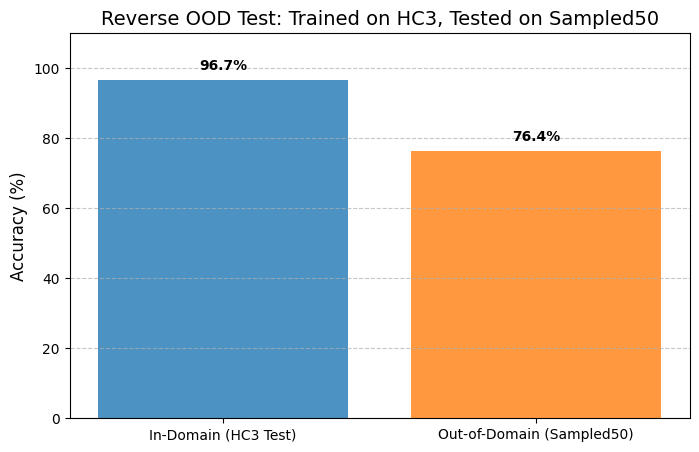

In [ ]:
import matplotlib.pyplot as plt

print("\n[Evaluating the HC3-Only Model...]")

# 1. In-Domain Evaluation (HC3 Test Set)
hc3_id_results = hc3_trainer.evaluate(hc3_tokenized['test'])
hc3_id_acc = hc3_id_results.get('eval_accuracy', 0.0) * 100

# 2. Out-of-Domain Evaluation (Original sampled_50 Test Set)
# tokenized_ds['test'] is the test split from the very beginning (sampled_50_dataset)
hc3_ood_results = hc3_trainer.evaluate(tokenized_ds['test'])
hc3_ood_acc = hc3_ood_results.get('eval_accuracy', 0.0) * 100

print(f"-> In-Domain Accuracy (HC3): {hc3_id_acc:.2f}%")
print(f"-> OOD Accuracy (Sampled50): {hc3_ood_acc:.2f}%")

# 3. Visualization
labels = ['In-Domain (HC3 Test)', 'Out-of-Domain (Sampled50)']
accuracies = [hc3_id_acc, hc3_ood_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accuracies, color=['tab:blue', 'tab:orange'], alpha=0.8)
plt.title('Reverse OOD Test: Trained on HC3, Tested on Sampled50', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 110)

# Add text labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()